# 06 — Model Monitoring & Governance

**Input:** `data/cs_features.parquet`, `models/xgb_final.json`, `models/lr_final.pkl`, `models/scaler.pkl`  
**Output:** Monitoring dashboard and governance report in `reports/`

**PSI thresholds:** < 0.10 No change ✓ | 0.10–0.25 Monitor ⚠️ | > 0.25 Retrain 🚨

---

In [16]:
import os, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
%matplotlib inline

os.makedirs('reports', exist_ok=True)

PAL  = {'good':'#1D9E75','bad':'#D85A30','neutral':'#378ADD','warn':'#EF9F27'}
SEED = 42

df    = pd.read_parquet('data/cs_features.parquet')
X_all = df.drop(columns='default')
y_all = df['default']
model = xgb.XGBClassifier()
model.load_model('models/xgb_final.json')
scaler = joblib.load('models/scaler.pkl')
lr     = joblib.load('models/lr_final.pkl')
print(f'Dataset: {df.shape[0]:,} rows  |  Models loaded')

Dataset: 149,999 rows  |  Models loaded


## 1. PSI Functions

In [10]:
def psi(expected, actual, bins=10):
    bp  = np.unique(np.percentile(expected, np.linspace(0,100,bins+1)))
    ep  = np.histogram(expected, bins=bp)[0] / len(expected)
    ap  = np.histogram(actual,   bins=bp)[0] / len(actual)
    ep  = np.where(ep==0, 0.0001, ep)
    ap  = np.where(ap==0, 0.0001, ap)
    return np.sum((ap-ep) * np.log(ap/ep))

def psi_label(v):
    if v < 0.10: return ('No shift',    PAL['good'])
    if v < 0.25: return ('Moderate',    PAL['warn'])
    return             ('Major shift',  PAL['bad'])

print('PSI functions ready')

PSI functions ready


## 2. Simulate Monthly Windows

In [11]:
np.random.seed(SEED)
n_train = int(0.5 * len(df))
df_base = df.iloc[:n_train].copy()
df_fut  = df.iloc[n_train:].copy()
n_win   = 6; wsize = len(df_fut) // n_win

windows = []
for i in range(n_win):
    chunk = df_fut.iloc[i*wsize:(i+1)*wsize].copy()
    if i >= 3:
        for col in X_all.columns[:2]:
            chunk[col] = chunk[col] + (i-2)*0.05
    windows.append({'month':f'M+{i+1}','data':chunk})

X_base     = df_base.drop(columns='default')
y_base     = df_base['default']
base_probs = model.predict_proba(X_base)[:,1]
print(f'Baseline: {len(df_base):,} rows  |  Windows: {n_win} x ~{wsize:,} rows')

Baseline: 74,999 rows  |  Windows: 6 x ~12,500 rows


## 3. PSI & Performance Over Time

In [12]:
psi_results = []
for w in windows:
    Xw = w['data'].drop(columns='default'); yw = w['data']['default']
    pw = model.predict_proba(Xw)[:,1]
    auc = roc_auc_score(yw, pw); psi_val = psi(base_probs, pw)
    label, _ = psi_label(psi_val)
    psi_results.append({'month':w['month'],'PSI':psi_val,'AUC':auc,
                         'Gini':2*auc-1,'default_rate':yw.mean()*100,'status':label})

psi_df = pd.DataFrame(psi_results)
display(psi_df.style.format({'PSI':'{:.4f}','AUC':'{:.4f}','Gini':'{:.4f}','default_rate':'{:.2f}%'})
        .bar(subset='PSI', color=PAL['bad']))

,month,PSI,AUC,Gini,default_rate,status
0,M+1,0.0010,0.9047,0.8094,6.46%,No shift
1,M+2,0.0009,0.9058,0.8117,6.89%,No shift
2,M+3,0.0007,0.9088,0.8176,6.58%,No shift
3,M+4,0.0079,0.8947,0.7895,6.45%,No shift
4,M+5,0.0411,0.8901,0.7803,6.74%,No shift
5,M+6,0.1405,0.9026,0.8051,7.12%,Moderate


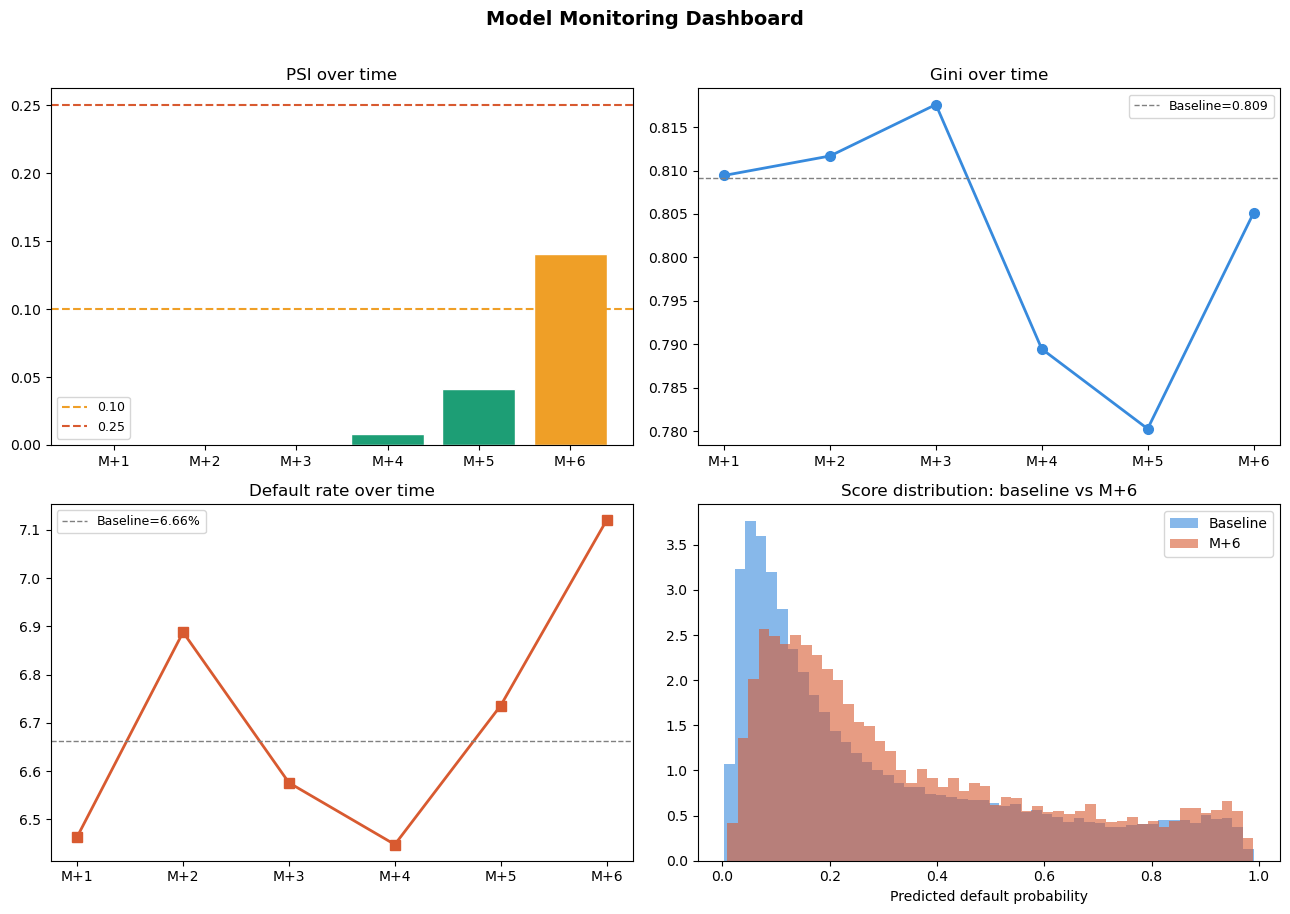

In [13]:
fig, axes = plt.subplots(2,2,figsize=(13,9))
bar_colors = [psi_label(v)[1] for v in psi_df['PSI']]
axes[0,0].bar(psi_df['month'], psi_df['PSI'], color=bar_colors, edgecolor='white')
axes[0,0].axhline(0.10, color=PAL['warn'], ls='--', lw=1.5, label='0.10')
axes[0,0].axhline(0.25, color=PAL['bad'],  ls='--', lw=1.5, label='0.25')
axes[0,0].set_title('PSI over time'); axes[0,0].legend(fontsize=9)

gini_base = 2*roc_auc_score(y_base, base_probs)-1
axes[0,1].plot(psi_df['month'], psi_df['Gini'], 'o-', color=PAL['neutral'], lw=2, ms=7)
axes[0,1].axhline(gini_base, color='gray', ls='--', lw=1, label=f'Baseline={gini_base:.3f}')
axes[0,1].set_title('Gini over time'); axes[0,1].legend(fontsize=9)

axes[1,0].plot(psi_df['month'], psi_df['default_rate'], 's-', color=PAL['bad'], lw=2, ms=7)
axes[1,0].axhline(y_base.mean()*100, color='gray', ls='--', lw=1,
                   label=f'Baseline={y_base.mean()*100:.2f}%')
axes[1,0].set_title('Default rate over time'); axes[1,0].legend(fontsize=9)

pl = model.predict_proba(windows[-1]['data'].drop(columns='default'))[:,1]
axes[1,1].hist(base_probs, bins=50, color=PAL['neutral'], alpha=0.6, density=True, label='Baseline')
axes[1,1].hist(pl,         bins=50, color=PAL['bad'],     alpha=0.6, density=True, label='M+6')
axes[1,1].set_xlabel('Predicted default probability')
axes[1,1].set_title('Score distribution: baseline vs M+6'); axes[1,1].legend()

plt.suptitle('Model Monitoring Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/monitoring_dashboard.png', bbox_inches='tight')
plt.show()

## 4. Champion-Challenger

Model                       AUC     Gini   Features
----------------------------------------------------
Champion (XGB Full)      0.9075   0.8150         18
Challenger (XGB Top8)    0.8700   0.7400          8

Winner: Champion


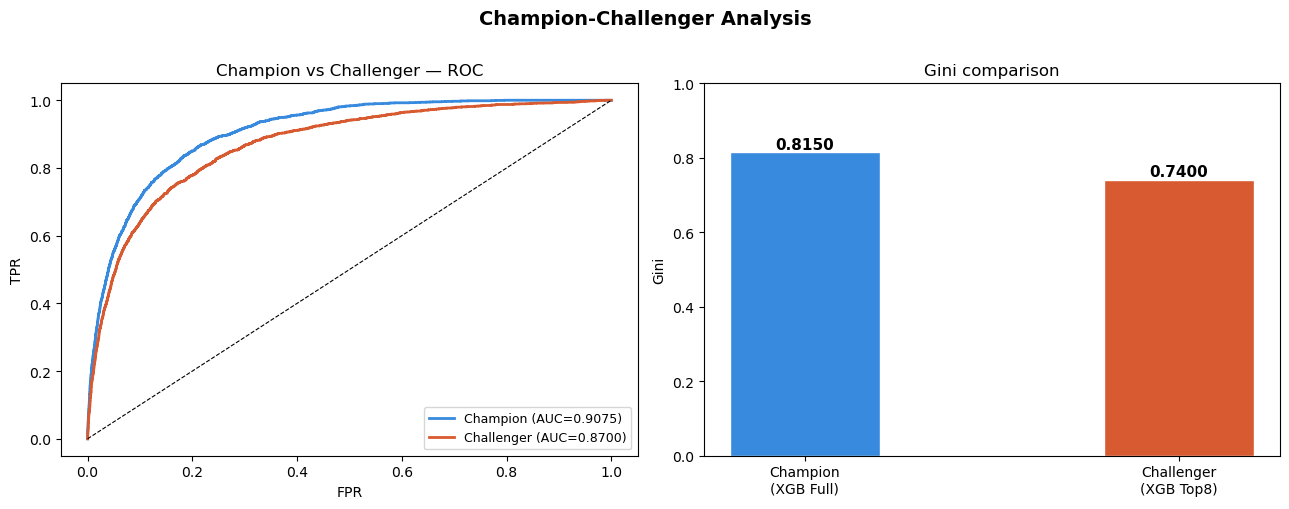

In [14]:
X_tr,X_te,y_tr,y_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)

champ_p    = model.predict_proba(X_te)[:,1]
champ_auc  = roc_auc_score(y_te, champ_p); champ_gini = 2*champ_auc-1

top8 = X_all.columns[:8].tolist()
challenger = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
    eval_metric='auc', use_label_encoder=False, random_state=SEED)
challenger.fit(X_tr[top8], y_tr)
chall_p   = challenger.predict_proba(X_te[top8])[:,1]
chall_auc = roc_auc_score(y_te, chall_p); chall_gini = 2*chall_auc-1

print(f'{"Model":<22} {"AUC":>8} {"Gini":>8} {"Features":>10}')
print('-'*52)
print(f'{"Champion (XGB Full)":<22} {champ_auc:>8.4f} {champ_gini:>8.4f} {len(X_all.columns):>10}')
print(f'{"Challenger (XGB Top8)":<22} {chall_auc:>8.4f} {chall_gini:>8.4f} {len(top8):>10}')
winner = 'Champion' if champ_gini >= chall_gini else 'Challenger'
print(f'\nWinner: {winner}')

fig, axes = plt.subplots(1,2,figsize=(13,5))
for name,probs,color in [('Champion',champ_p,PAL['neutral']),('Challenger',chall_p,PAL['bad'])]:
    fpr,tpr,_ = roc_curve(y_te, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc_score(y_te,probs):.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Champion vs Challenger — ROC'); axes[0].legend(fontsize=9)

axes[1].bar(['Champion\n(XGB Full)','Challenger\n(XGB Top8)'],
             [champ_gini,chall_gini], color=[PAL['neutral'],PAL['bad']], edgecolor='white', width=0.4)
axes[1].set_ylabel('Gini'); axes[1].set_title('Gini comparison'); axes[1].set_ylim(0,1)
for bar,v in zip(axes[1].patches,[champ_gini,chall_gini]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.4f}',
                  ha='center', fontsize=11, fontweight='bold')
plt.suptitle('Champion-Challenger Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/champion_challenger.png', bbox_inches='tight')
plt.show()

## 5. Governance Report

In [15]:
report = f"""# Model Monitoring Report

## Model Details
- Champion: XGBoost (n_estimators=500, max_depth=5, lr=0.05)
- Dataset: Give Me Some Credit — 150,000 observations
- Training default rate: {y_all.mean()*100:.2f}%

## Baseline Performance
- AUC:  {champ_auc:.4f}
- Gini: {champ_gini:.4f}

## Monitoring Results
| Month | PSI | Status | Gini | Default Rate |
|---|---|---|---|---|
"""
for _, row in psi_df.iterrows():
    report += f"| {row['month']} | {row['PSI']:.4f} | {row['status']} | {row['Gini']:.4f} | {row['default_rate']:.2f}% |\n"

report += f"""
## Champion-Challenger
- Champion Gini: {champ_gini:.4f}
- Challenger Gini: {chall_gini:.4f}
- Outcome: {winner} retained

## Recommended Actions
- Monthly PSI monitoring
- Model review if PSI > 0.25
- Retrain if Gini drops > 5 points
- Quarterly champion-challenger
"""

with open('reports/monitoring_report.md', 'w') as f:
    f.write(report)

print(report)

# Model Monitoring Report

## Model Details
- Champion: XGBoost (n_estimators=500, max_depth=5, lr=0.05)
- Dataset: Give Me Some Credit — 150,000 observations
- Training default rate: 6.68%

## Baseline Performance
- AUC:  0.9075
- Gini: 0.8150

## Monitoring Results
| Month | PSI | Status | Gini | Default Rate |
|---|---|---|---|---|
| M+1 | 0.0010 | No shift | 0.8094 | 6.46% |
| M+2 | 0.0009 | No shift | 0.8117 | 6.89% |
| M+3 | 0.0007 | No shift | 0.8176 | 6.58% |
| M+4 | 0.0079 | No shift | 0.7895 | 6.45% |
| M+5 | 0.0411 | No shift | 0.7803 | 6.74% |
| M+6 | 0.1405 | Moderate | 0.8051 | 7.12% |

## Champion-Challenger
- Champion Gini: 0.8150
- Challenger Gini: 0.7400
- Outcome: Champion retained

## Recommended Actions
- Monthly PSI monitoring
- Model review if PSI > 0.25
- Retrain if Gini drops > 5 points
- Quarterly champion-challenger

